<a href="https://colab.research.google.com/github/jorgecedraz/PPEC0039---ESTATISTICA/blob/main/TESTEDEHIP%C3%93TESE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Teste de Hipótese para uma Média**

Aplicação no Projeto: Validação Ambiental (Imobilização dos Contaminantes das cinzas de biomassa).

As cinzas de biomassa da minha pesquisa possui níveis de Cromo de 0,08 mg/L, classificando-o como Classe II-A (Não perigoso, não inerte), e a norma estabelece o limite de solubilização em 0,05 mg/L. Após a hidratação do cimento, será feito o ensaio de lixiviação/solubilização para provar que o cimento imobilizou o contaminante.

In [7]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# 1. Entrada de Dados
# Os resultados de lixiviação de 6 corpos de prova do cimento CSAB (em mg/L)
resultados_bancada = np.array([0.035, 0.041, 0.038, 0.045, 0.039, 0.042])

limite_norma = 0.05 # Limite para reclassificação Classe II-B (Não perigoso, inerte)
alfa = 0.05 # Nível de significância (5%)

n = len(resultados_bancada)
media_amostral = np.mean(resultados_bancada)
desvio_padrao_amostral = np.std(resultados_bancada, ddof=1)
graus_liberdade = n - 1

print("--- RESULTADOS DO ENSAIO DE LIXIVIAÇÃO ---")
print(f"Média obtida no CSAB: {media_amostral:.4f} mg/L")
print(f"Desvio Padrão: {desvio_padrao_amostral:.4f} mg/L\n")


--- RESULTADOS DO ENSAIO DE LIXIVIAÇÃO ---
Média obtida no CSAB: 0.0400 mg/L
Desvio Padrão: 0.0035 mg/L



In [8]:
# 2. Execução do Teste de Hipótese (Unilateral à esquerda)
# O parâmetro alternative='less' testa se a nossa amostra é menor que o limite da norma
t_stat, p_valor = stats.ttest_1samp(resultados_bancada, popmean=limite_norma, alternative='less')

print("--- ANÁLISE ESTATÍSTICA ---")
print(f"Estatística t calculada: {t_stat:.4f}")
print(f"Valor-p (p-value): {p_valor:.6f}")

if p_valor < alfa:
    print("\nCONCLUSÃO: Rejeitamos H0.")
    print("Há evidências estatísticas significativas de que a lixiviação média de Cromo é INFERIOR a 0.05 mg/L.")
    print("O mecanismo de encapsulamento nas fases AFm foi validado. Produto Classe II-B (Não perigoso, inerte).")
else:
    print("\nCONCLUSÃO: Falhamos em rejeitar H0.")
    print("Não há evidências estatísticas suficientes para provar que a lixiviação está abaixo da norma.")
    print("O nível de Cromo ainda é considerado de risco Classe II-A (Não perigoso, não inerte).")

--- ANÁLISE ESTATÍSTICA ---
Estatística t calculada: -7.0711
Valor-p (p-value): 0.000438

CONCLUSÃO: Rejeitamos H0.
Há evidências estatísticas significativas de que a lixiviação média de Cromo é INFERIOR a 0.05 mg/L.
O mecanismo de encapsulamento nas fases AFm foi validado. Produto Classe II-B (Não perigoso, inerte).


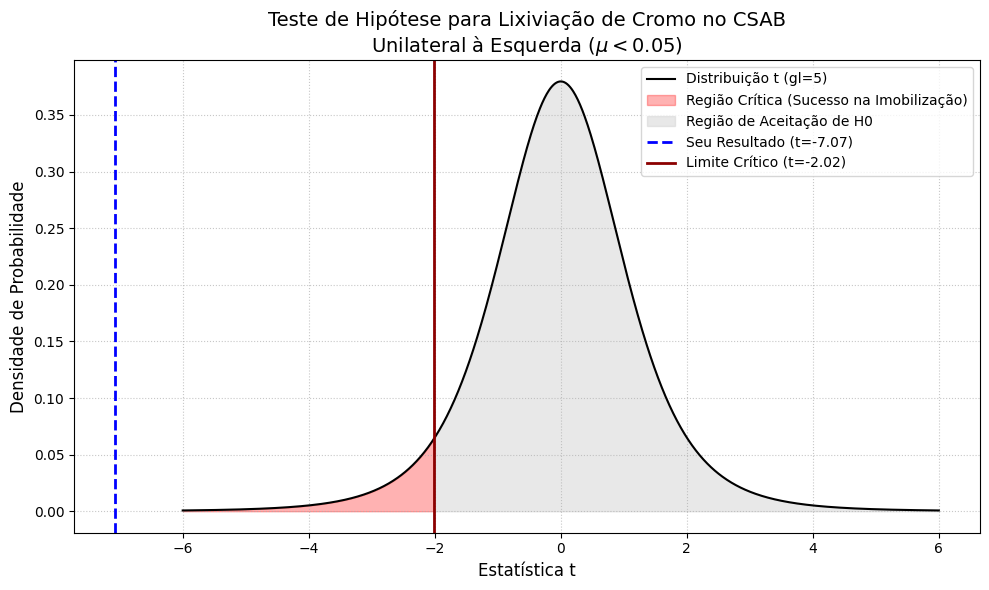

In [10]:
# 3. Visualização Gráfica (Região Crítica e Aceitação)
# Gerando a curva da distribuição t de Student
t_dist = np.linspace(-6, 6, 1000)
pdf_dist = stats.t.pdf(t_dist, df=graus_liberdade)

# Determinando o t crítico para a cauda esquerda
t_critico = stats.t.ppf(alfa, df=graus_liberdade)

plt.figure(figsize=(10, 6))
plt.plot(t_dist, pdf_dist, color='black', label=f'Distribuição t (gl={graus_liberdade})')

# Preenchendo a Região Crítica (Rejeição de H0)
plt.fill_between(t_dist, pdf_dist, where=(t_dist < t_critico), color='red', alpha=0.3, label='Região Crítica (Sucesso na Imobilização)')

# Preenchendo a Região de Aceitação (Falha em rejeitar H0)
plt.fill_between(t_dist, pdf_dist, where=(t_dist >= t_critico), color='lightgray', alpha=0.5, label='Região de Aceitação de H0')

# Marcando o valor obtido na bancada
plt.axvline(t_stat, color='blue', linestyle='--', linewidth=2, label=f'Seu Resultado (t={t_stat:.2f})')
plt.axvline(t_critico, color='darkred', linestyle='-', linewidth=2, label=f'Limite Crítico (t={t_critico:.2f})')

plt.title('Teste de Hipótese para Lixiviação de Cromo no CSAB\nUnilateral à Esquerda ($\\mu < 0.05$)', fontsize=14)
plt.xlabel('Estatística t', fontsize=12)
plt.ylabel('Densidade de Probabilidade', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()